In [1]:
import numpy as np

from TimeSeriesGeneratorV2 import EventTimestampGenerator, EventSampleSpace, TimeSeriesGenerator

In [2]:
N = 3
cycles = 2
time_intervals = [(i, i+1) for i in range(N)]
occurrences = [i+1 for i in range(N)]
noise_sds = [0]*N
no_occurrences_sds = [1]*N

print("Time intervals:", time_intervals)
print("Occurrences:", occurrences)
print("Period standard deviations:", noise_sds)
print("Number of occurrences standard deviations:", no_occurrences_sds)

Time intervals: [(0, 1), (1, 2), (2, 3)]
Occurrences: [1, 2, 3]
Period standard deviations: [0, 0, 0]
Number of occurrences standard deviations: [1, 1, 1]


In [3]:
class ExampleETG(EventTimestampGenerator):
    """Class representing the frequency of events over time, defined by occurrences and time intervals"""
    def __init__(self, occurrences, time_intervals, noise_sds, occurrences_sds):
        self.noise_sds = noise_sds
        self.occurrences_sds = occurrences_sds
        super().__init__(occurrences, time_intervals)
        
        
    def sample_noise (self, i):
        """Samples a timing interval"""
        return np.random.normal(loc=0, scale=self.noise_sds[i])
    
    def sample_occurrences(self, occurrences_i, i):
        sample = int(np.round(np.random.normal(loc=occurrences_i, scale=self.occurrences_sds[i])))
        return sample


class ExampleSampleSpace(EventSampleSpace):
    def __init__(self):
        super().__init__()
    
    def sample(self, t):
        sample = np.random.normal(loc=1, scale=0)
        return .5 if sample <= .5 else sample

In [4]:
etg = ExampleETG(occurrences, time_intervals, noise_sds, no_occurrences_sds)
ess = ExampleSampleSpace()

In [5]:
import logging

logger = logging.getLogger(__name__)

# Configure root logger once:
logging.basicConfig(
    level=logging.DEBUG,                            # show DEBUG+ messages
    format="%(asctime)s %(name)s %(levelname)s: %(message)s",
)

def on_event(event):
    logger.info(f"event: {event}")
    logger.info("--------")

time_series_generator = TimeSeriesGenerator([(etg, ess)], on_event)
data = time_series_generator.run(cycles*N, real_time=True)
logger.info(f"Generated data: {data}")

2025-07-30 15:23:10,690 utils DEBUG: Checks if constraint is satisfied with value: 1.25
2025-07-30 15:23:10,691 utils DEBUG: Constraint satisfied
2025-07-30 15:23:10,691 TimeSeriesGeneratorV2 DEBUG: 1.25 s ahead of time - sleeping.
2025-07-30 15:23:11,942 __main__ INFO: event: (1.25, 1.0)
2025-07-30 15:23:11,942 __main__ INFO: --------
2025-07-30 15:23:11,943 utils DEBUG: Checks if constraint is satisfied with value: 1.5
2025-07-30 15:23:11,943 utils DEBUG: Constraint satisfied
2025-07-30 15:23:11,943 TimeSeriesGeneratorV2 DEBUG: 0.25 s ahead of time - sleeping.
2025-07-30 15:23:12,194 __main__ INFO: event: (1.5, 1.0)
2025-07-30 15:23:12,194 __main__ INFO: --------
2025-07-30 15:23:12,195 utils DEBUG: Checks if constraint is satisfied with value: 1.75
2025-07-30 15:23:12,195 utils DEBUG: Constraint satisfied
2025-07-30 15:23:12,195 TimeSeriesGeneratorV2 DEBUG: 0.25 s ahead of time - sleeping.
2025-07-30 15:23:12,446 __main__ INFO: event: (1.75, 1.0)
2025-07-30 15:23:12,447 __main__ INF

2025-07-30 15:23:16,515 matplotlib DEBUG: matplotlib data path: /home/buster/anaconda3/envs/uio-dt-sdg/lib/python3.13/site-packages/matplotlib/mpl-data
2025-07-30 15:23:16,523 matplotlib DEBUG: CONFIGDIR=/home/buster/.config/matplotlib
2025-07-30 15:23:16,535 matplotlib DEBUG: interactive is False
2025-07-30 15:23:16,536 matplotlib DEBUG: platform is linux
2025-07-30 15:23:16,571 matplotlib DEBUG: CACHEDIR=/home/buster/.cache/matplotlib
2025-07-30 15:23:16,573 matplotlib.font_manager DEBUG: Using fontManager instance from /home/buster/.cache/matplotlib/fontlist-v390.json
2025-07-30 15:23:16,693 matplotlib.pyplot DEBUG: Loaded backend module://matplotlib_inline.backend_inline version unknown.
2025-07-30 15:23:16,695 matplotlib.pyplot DEBUG: Loaded backend module://matplotlib_inline.backend_inline version unknown.
2025-07-30 15:23:16,697 matplotlib.font_manager DEBUG: findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=10.0.
2025-07-30 15:23:16,69

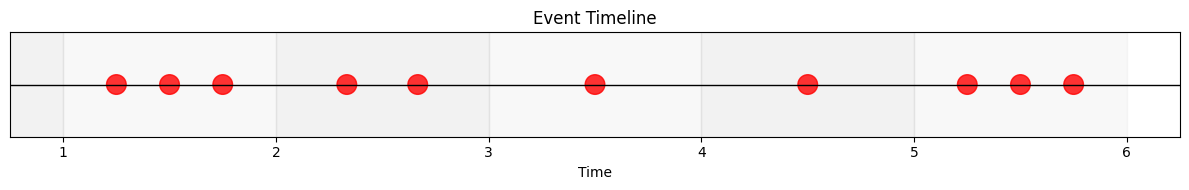

In [6]:
from Analytics import plot_timeline, extend_intervals
plot_timeline(data, extend_intervals(time_intervals, cycles))


In [7]:
from Analytics import count_number_of_occurrences_in_intervals
count_number_of_occurrences_in_intervals(extend_intervals(time_intervals, cycles), data)

[0, 3, 2, 1, 1, 3]